<a href="https://colab.research.google.com/github/hyahiku/hyahiku.github.io/blob/main/CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 - Load & Clean the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# Load from HuggingFace
from datasets import load_dataset

dataset = load_dataset("previdengue/predict_climate_data", split="train")

# Convert to pandas DataFrame
df = dataset.to_pandas()

print(f"✅ Loaded {len(df):,} records from HuggingFace")
print(f"   Columns: {list(df.columns)}")

✅ Loaded 3,548,090 records from HuggingFace
   Columns: ['codigo_ibge', 'municipio', 'ano_semana', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR']


In [ ]:
# VERIFY THE DATA
# Basic info about your dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

# Preview first few rows
df.head(10)

DATASET OVERVIEW
Number of rows: 3,548,090
Number of columns: 9

Column names: ['codigo_ibge', 'municipio', 'ano_semana', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR']

Data types:
codigo_ibge            int64
municipio             object
ano_semana            object
T2M                  float64
T2M_MAX              float64
T2M_MIN              float64
RH2M                 float64
ALLSKY_SFC_SW_DWN    float64
PRECTOTCORR          float64
dtype: object


,codigo_ibge,municipio,ano_semana,T2M,T2M_MAX,T2M_MIN,RH2M,ALLSKY_SFC_SW_DWN,PRECTOTCORR
0,1100015,Alta Floresta D'Oeste,2014/01,24.855715,27.414286,22.611430,91.055720,19.351429,22.910000
1,1100015,Alta Floresta D'Oeste,2014/02,23.854284,26.605715,21.244287,92.781425,17.184286,86.850000
2,1100015,Alta Floresta D'Oeste,2014/03,24.161428,27.350000,21.414286,91.968575,17.770000,77.040000
3,1100015,Alta Floresta D'Oeste,2014/04,24.150000,26.712858,22.282856,93.290000,16.028572,59.430000
4,1100015,Alta Floresta D'Oeste,2014/05,23.184286,25.869999,21.289999,93.605710,15.895715,62.280003
5,1100015,Alta Floresta D'Oeste,2014/06,23.712858,26.584286,21.292858,91.912860,17.045713,60.470000
6,1100015,Alta Floresta D'Oeste,2014/07,23.778570,26.632856,21.552856,93.015710,16.128572,75.410000
7,1100015,Alta Floresta D'Oeste,2014/08,24.078571,26.811428,22.020000,93.112854,15.498572,59.670002
8,1100015,Alta Floresta D'Oeste,2014/09,24.712858,27.994287,22.174286,90.950005,17.735714,24.480000
9,1100015,Alta Floresta D'Oeste,2014/10,24.420000,27.371430,22.041428,92.250000,16.315714,53.340000


In [ ]:
# Standardize column names - lower case letters

df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

['codigo_ibge', 'municipio', 'ano_semana', 't2m', 't2m_max', 't2m_min', 'rh2m', 'allsky_sfc_sw_dwn', 'prectotcorr']


In [ ]:
# Check for duplicate rows
print("=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()
duplicate_pct = (duplicates / len(df) * 100)

print(f"\nTotal rows: {len(df):,}")
print(f"Duplicate rows: {duplicates:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

if duplicates > 0:
    print("\n⚠️ Sample duplicate rows:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("\n✅ No duplicate rows found!")

DUPLICATE RECORDS ANALYSIS

Total rows: 3,548,090
Duplicate rows: 0
Duplicate percentage: 0.00%

✅ No duplicate rows found!


In [ ]:
# DATA QUALITY ASSESSMENT

# Check for missing values
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ No missing values found!")

print(f"\nTotal cells: {df.size:,}")
print(f"Missing cells: {df.isnull().sum().sum():,}")
print(f"Completeness: {(1 - df.isnull().sum().sum() / df.size) * 100:.2f}%")

MISSING VALUES ANALYSIS

✅ No missing values found!

Total cells: 31,932,810
Missing cells: 0
Completeness: 100.00%


In [ ]:
# Parse ano_semana into year and week columns
df[['year', 'week']] = df['ano_semana'].str.split('/', expand=True)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['week'] = pd.to_numeric(df['week'], errors='coerce')

# Check for any invalid year or week values
print("Invalid years:", df['year'].isnull().sum())
print("Invalid weeks:", df['week'].isnull().sum())

print("Week min:", df['week'].min())
print("Week max:", df['week'].max())

Invalid years: 0
Invalid weeks: 0
Week min: 1
Week max: 53


In [ ]:
# Identify numeric columns and check for outliers
print("=" * 60)
print("OUTLIER ANALYSIS (Numeric Columns)")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns found: {numeric_cols}")

if len(numeric_cols) > 0:
    for col in numeric_cols[:5]:  # Limit to first 5 numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_pct = len(outliers) / len(df) * 100

        print(f"\n📊 {col}:")
        print(f"   Range: {df[col].min():.2f} to {df[col].max():.2f}")
        print(f"   Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")
        print(f"   Outliers: {len(outliers):,} ({outlier_pct:.1f}%)")
else:
    print("\nNo numeric columns found for outlier analysis.")

OUTLIER ANALYSIS (Numeric Columns)

Numeric columns found: ['codigo_ibge', 't2m', 't2m_max', 't2m_min', 'rh2m', 'allsky_sfc_sw_dwn', 'prectotcorr', 'year', 'week']

📊 codigo_ibge:
   Range: 1100015.00 to 5300108.00
   Mean: 3253590.77, Median: 3146280.00
   Outliers: 0 (0.0%)

📊 t2m:
   Range: -416.38 to 37.81
   Mean: 23.23, Median: 24.62
   Outliers: 89,095 (2.5%)

📊 t2m_max:
   Range: -413.95 to 44.75
   Mean: 29.21, Median: 29.90
   Outliers: 72,359 (2.0%)

📊 t2m_min:
   Range: -418.63 to 31.37
   Mean: 18.38, Median: 19.79
   Outliers: 48,165 (1.4%)

📊 rh2m:
   Range: -402.08 to 96.83
   Mean: 70.71, Median: 74.45
   Outliers: 56,013 (1.6%)


In [ ]:
# Remove invalid values
valid_ranges = {
    't2m': (-50, 60),
    't2m_max': (-50, 60),
    't2m_min': (-50, 60),
    'rh2m': (0, 100),
    'allsky_sfc_sw_dwn': (0, 500),
    'prectotcorr': (0, 500)
}

for col, (low, high) in valid_ranges.items():
    df = df[(df[col] >= low) & (df[col] <= high)]

In [ ]:
# Verify removed invalid values
invalid_counts = {}

for col, (low, high) in valid_ranges.items():
    invalid_counts[col] = ((df[col] < low) | (df[col] > high)).sum()

print(invalid_counts)

{'t2m': np.int64(0), 't2m_max': np.int64(0), 't2m_min': np.int64(0), 'rh2m': np.int64(0), 'allsky_sfc_sw_dwn': np.int64(0), 'prectotcorr': np.int64(0)}


In [ ]:
# Sanity check for removed data

original_rows = 3548090  # your original count
current_rows = len(df)

removed = original_rows - current_rows
removed_pct = (removed / original_rows) * 100

print(f"Rows removed: {removed:,}")
print(f"Percent removed: {removed_pct:.2f}%")

# Re-check ranges
print(df[['t2m','t2m_max','t2m_min','rh2m','allsky_sfc_sw_dwn','prectotcorr']].describe())

# Re-check temperature relationships are reasonable
invalid_temp_order = df[
    (df['t2m_min'] > df['t2m']) |
    (df['t2m'] > df['t2m_max'])
]

print("Invalid temp ordering rows:", len(invalid_temp_order))

Rows removed: 40,139
Percent removed: 1.13%
                t2m       t2m_max       t2m_min          rh2m  \
count  3.507951e+06  3.507951e+06  3.507951e+06  3.507951e+06   
mean   2.391972e+01  2.990337e+01  1.906142e+01  7.145941e+01   
std    4.162760e+00  4.537676e+00  4.342235e+00  1.381851e+01   
min    4.010000e+00  8.548572e+00 -3.842857e-01  1.821857e+01   
25%    2.162143e+01  2.735857e+01  1.643429e+01  6.336715e+01   
50%    2.462143e+01  2.990571e+01  1.979000e+01  7.450714e+01   
75%    2.677143e+01  3.303286e+01  2.234857e+01  8.211285e+01   
max    3.781286e+01  4.474857e+01  3.136857e+01  9.683428e+01   

       allsky_sfc_sw_dwn   prectotcorr  
count       3.507951e+06  3.507951e+06  
mean        1.892453e+01  2.238093e+01  
std         4.288459e+00  2.727635e+01  
min         2.960000e+00  0.000000e+00  
25%         1.617714e+01  2.090000e+00  
50%         1.911571e+01  1.270000e+01  
75%         2.194286e+01  3.304000e+01  
max         3.237429e+01  4.216800e+02  
I

# Phase 2 - Cluster into Weather Profiles

In [ ]:
df['temp_range'] = df['t2m_max'] - df['t2m_min']

df['rain_flag'] = (df['prectotcorr'] > df['prectotcorr'].median()).astype(int)
df['high_humidity'] = (df['rh2m'] > 85).astype(int)

In [ ]:
city_profile = (
    df.groupby(['codigo_ibge', 'municipio'])
    .agg({
        't2m': ['mean', 'std'],
        't2m_max': 'mean',
        't2m_min': 'mean',
        'rh2m': ['mean', 'std'],
        'allsky_sfc_sw_dwn': ['mean', 'std'],
        'prectotcorr': ['mean', 'std'],
        'temp_range': 'mean'
    })
)

city_profile.columns = ['_'.join(col).strip() for col in city_profile.columns]
city_profile = city_profile.reset_index()

print(city_profile.head())

   codigo_ibge              municipio   t2m_mean   t2m_std  t2m_max_mean  \
0      1100015  Alta Floresta D'Oeste  26.105306  2.302196     31.013791   
1      1100023              Ariquemes  26.999023  2.157955     31.713390   
2      1100031                 Cabixi  26.253938  2.430185     31.366561   
3      1100049                 Cacoal  26.881077  2.347090     31.965081   
4      1100056             Cerejeiras  25.610334  2.241593     30.576112   

   t2m_min_mean  rh2m_mean   rh2m_std  allsky_sfc_sw_dwn_mean  \
0     21.957694  75.524805  17.559558               18.286977   
1     22.982907  77.850501  15.608908               17.759347   
2     21.841426  75.078065  17.968049               18.235019   
3     22.538812  74.557045  18.194060               18.288365   
4     21.416598  76.156209  16.961087               18.235019   

   allsky_sfc_sw_dwn_std  prectotcorr_mean  prectotcorr_std  temp_range_mean  
0               2.126060         27.093730        28.712670         9.056

In [ ]:
print(city_profile.describe())

        codigo_ibge     t2m_mean      t2m_std  t2m_max_mean  t2m_min_mean  \
count  5.570000e+03  5570.000000  5570.000000   5570.000000   5570.000000   
mean   3.253591e+06    23.923849     2.583471     29.907444     19.065806   
std    9.849103e+05     3.131648     0.923588      3.223183      3.397364   
min    1.100015e+06    15.487611     0.397659     20.820856     11.152102   
25%    2.512126e+06    21.491791     2.001109     27.643105     16.486175   
50%    3.146280e+06    24.408240     2.330743     30.458560     19.045533   
75%    4.119190e+06    26.555385     3.185714     32.239612     21.879002   
max    5.300108e+06    29.565478     5.732128     36.294947     26.989176   

         rh2m_mean     rh2m_std  allsky_sfc_sw_dwn_mean  \
count  5570.000000  5570.000000             5570.000000   
mean     71.454327    10.574610               18.926580   
std       7.897240     4.127745                1.670690   
min      51.616594     1.540845               14.452719   
25%      65

In [ ]:
cluster_cols = [
    't2m_mean', 't2m_std',
    'rh2m_mean', 'rh2m_std',
    'allsky_sfc_sw_dwn_mean', 'allsky_sfc_sw_dwn_std',
    'prectotcorr_mean', 'prectotcorr_std',
    'temp_range_mean'
]

X = city_profile[cluster_cols]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.349
k=3, silhouette score=0.352
k=4, silhouette score=0.312
k=5, silhouette score=0.342
k=6, silhouette score=0.369


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
city_profile['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = city_profile.groupby('cluster')[cluster_cols].mean().round(2)
print(cluster_summary)

         t2m_mean  t2m_std  rh2m_mean  rh2m_std  allsky_sfc_sw_dwn_mean  \
cluster                                                                   
0           26.29     2.13      63.36     13.57                   20.50   
1           22.60     2.65      72.37      9.58                   18.42   
2           26.77     1.62      77.60     10.04                   19.10   
3           19.45     4.05      80.11      7.06                   16.70   

         allsky_sfc_sw_dwn_std  prectotcorr_mean  prectotcorr_std  \
cluster                                                             
0                         3.04             16.71            22.22   
1                         4.05             20.81            24.97   
2                         2.71             28.52            29.82   
3                         5.60             30.50            30.49   

         temp_range_mean  
cluster                   
0                  11.88  
1                  11.76  
2                   7.22  

In [ ]:
cluster_names = {
    0: "Hot and Dry",
    1: "Moderate and Balanced",
    2: "Hot, Humid, and Rainy",
    3: "Cool, Humid, and Variable"
}

In [ ]:
city_profile['climate_profile'] = city_profile['cluster'].map(cluster_names)

In [ ]:
city_profile[['municipio', 'climate_profile']].head()

,municipio,climate_profile
0,Alta Floresta D'Oeste,"Hot, Humid, and Rainy"
1,Ariquemes,"Hot, Humid, and Rainy"
2,Cabixi,"Hot, Humid, and Rainy"
3,Cacoal,"Hot, Humid, and Rainy"
4,Cerejeiras,"Hot, Humid, and Rainy"


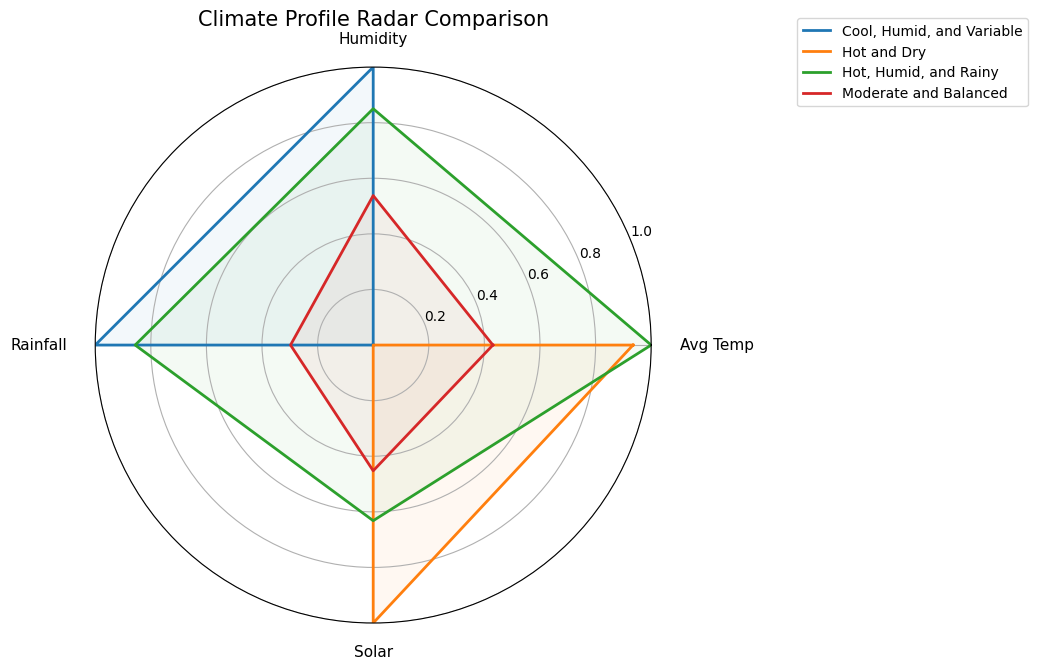

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use your normalized dataframe (scaled_df)
labels = scaled_df.columns.tolist()
num_vars = len(labels)

# Create angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Create plot
fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(polar=True))

# Plot each climate profile
for profile_name, row in scaled_df.iterrows():
    values = row.tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=profile_name)
    ax.fill(angles, values, alpha=0.05)

# Clean axis labels
pretty_labels = ["Avg Temp", "Humidity", "Rainfall", "Solar"]

# Set ticks and labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(pretty_labels, fontsize=11)

# Use smaller padding (more balanced)
ax.tick_params(axis='x', pad=10)

# Adjust alignment + rotation (cleanest solution)
for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    angle_deg = np.degrees(angle)

    # Rotate labels slightly so they follow the circle
    label.set_rotation(angle_deg)
    label.set_rotation_mode('anchor')

    if angle_deg == 0:  # Avg Temp (right)
        label.set_horizontalalignment('left')
    elif angle_deg == 180:  # Rainfall (left)
        label.set_horizontalalignment('right')
    else:
        label.set_horizontalalignment('center')

# Radial ticks
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])

# Set range
ax.set_ylim(0, 1)

# Title
ax.set_title("Climate Profile Radar Comparison", size=15, pad=30)

# Legend outside
ax.legend(loc='upper left', bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.show()

# Phase 4 - RAG System

In [ ]:
# Create text descriptions
city_profile['description'] = (
    "City with avg temp " + city_profile['t2m_mean'].round(1).astype(str) +
    ", humidity " + city_profile['rh2m_mean'].round(1).astype(str) +
    ", rainfall " + city_profile['prectotcorr_mean'].round(1).astype(str) +
    ", classified as " + city_profile['climate_profile']
)

In [ ]:
# Embed Descriptions
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(city_profile['description'].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Build retrieval function
def query_system(query, top_n=5):
    query_embedding = model.encode([query])

    scores = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = scores.argsort()[::-1][:top_n]

    return city_profile.iloc[top_indices][['municipio', 'description']]

Example Queries

In [ ]:
query_system("hot and humid cities")

,municipio,description
3804,Santo Antônio do Aracanguá,"City with avg temp 25.2, humidity 64.2, rainfa..."
3637,Nova Castilho,"City with avg temp 25.2, humidity 64.2, rainfa..."
3897,Valparaíso,"City with avg temp 25.2, humidity 64.2, rainfa..."
3298,Araçatuba,"City with avg temp 25.2, humidity 64.2, rainfa..."
1674,Craíbas,"City with avg temp 25.8, humidity 70.9, rainfa..."


Query 1 - Failed 💔

In [ ]:
query_system("cool regions with high rainfall")

,municipio,description
1462,Várzea,"City with avg temp 26.2, humidity 64.2, rainfa..."
1257,Areia de Baraúnas,"City with avg temp 26.2, humidity 64.2, rainfa..."
1287,Cacimbas,"City with avg temp 26.2, humidity 64.2, rainfa..."
1412,Santa Luzia,"City with avg temp 26.2, humidity 64.2, rainfa..."
1406,Salgadinho,"City with avg temp 26.2, humidity 64.2, rainfa..."


Query 2 - Failed 💔

In [ ]:
query_system("dry and sunny areas")

,municipio,description
1458,Tenório,"City with avg temp 26.2, humidity 64.2, rainfa..."
1455,Taperoá,"City with avg temp 26.2, humidity 64.2, rainfa..."
1406,Salgadinho,"City with avg temp 26.2, humidity 64.2, rainfa..."
1339,Juazeirinho,"City with avg temp 26.2, humidity 64.2, rainfa..."
1434,São José do Sabugi,"City with avg temp 26.2, humidity 64.2, rainfa..."


Query 3 - Pass, but could be better 💙

In [ ]:
# Add qualitative descriptors
# Referenced to query 1

def temp_category(x):
    if x >= 26:
        return "hot"
    elif x >= 22:
        return "moderate"
    else:
        return "cool"

def humidity_category(x):
    if x >= 75:
        return "humid"
    elif x >= 65:
        return "moderately humid"
    else:
        return "dry"

def rain_category(x):
    if x >= 25:
        return "high rainfall"
    elif x >= 15:
        return "moderate rainfall"
    else:
        return "low rainfall"

def solar_category(x):
    if x >= 20:
        return "high solar exposure"
    elif x >= 18:
        return "moderate solar exposure"
    else:
        return "low solar exposure"

city_profile["temp_category"] = city_profile["t2m_mean"].apply(temp_category)
city_profile["humidity_category"] = city_profile["rh2m_mean"].apply(humidity_category)
city_profile["rain_category"] = city_profile["prectotcorr_mean"].apply(rain_category)
city_profile["solar_category"] = city_profile["allsky_sfc_sw_dwn_mean"].apply(solar_category)

In [ ]:
def describe_row(row):
    return (
        f"This municipality is {row['temp_category']}, {row['humidity_category']}, "
        f"with {row['rain_category']} and {row['solar_category']}. "
        f"Average temperature is {row['t2m_mean']:.1f}°C, "
        f"average humidity is {row['rh2m_mean']:.1f}%, "
        f"average rainfall is {row['prectotcorr_mean']:.1f}, "
        f"and average solar radiation is {row['allsky_sfc_sw_dwn_mean']:.1f}. "
        f"Cluster-based climate profile: {row['climate_profile']}."
    )

city_profile["description"] = city_profile.apply(describe_row, axis=1)

In [ ]:
# Re-embed
embeddings = model.encode(city_profile["description"].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/175 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_query_system(query, top_n=5):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = scores.argsort()[::-1][:top_n]

    return city_profile.iloc[top_indices][[
        "municipio", "description", "climate_profile"
    ]].assign(score=scores[top_indices]).reset_index(drop=True)

In [ ]:
def parse_query_tags(query):
    query = query.lower()

    filters = {}

    if "hot" in query:
        filters["temp_category"] = "hot"
    elif "cool" in query:
        filters["temp_category"] = "cool"
    elif "moderate" in query:
        filters["temp_category"] = "moderate"

    if "humid" in query and "moderately humid" not in query:
        filters["humidity_category"] = "humid"
    elif "dry" in query:
        filters["humidity_category"] = "dry"

    if "high rainfall" in query or "rainy" in query:
        filters["rain_category"] = "high rainfall"
    elif "moderate rainfall" in query:
        filters["rain_category"] = "moderate rainfall"
    elif "low rainfall" in query:
        filters["rain_category"] = "low rainfall"

    if "sunny" in query or "high solar" in query:
        filters["solar_category"] = "high solar exposure"
    elif "low solar" in query or "cloudy" in query:
        filters["solar_category"] = "low solar exposure"

    return filters

In [ ]:
def hybrid_query_system(query, top_n=5):
    filters = parse_query_tags(query)
    filtered = city_profile.copy()

    for col, value in filters.items():
        filtered = filtered[filtered[col] == value]

    if len(filtered) == 0:
        return pd.DataFrame({
            "message": [f"No municipalities matched the structured filters for query: '{query}'"]
        })

    filtered_embeddings = model.encode(filtered["description"].tolist(), show_progress_bar=False)
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, filtered_embeddings)[0]

    top_indices = scores.argsort()[::-1][:top_n]
    results = filtered.iloc[top_indices][[
        "municipio",
        "temp_category",
        "humidity_category",
        "rain_category",
        "solar_category",
        "climate_profile",
        "description"
    ]].copy()

    results["score"] = scores[top_indices]
    return results.reset_index(drop=True)

Example Queries - Revision Verification

Query 1 Comparison

In [ ]:
semantic_query_system("hot and humid cities")

,municipio,description,climate_profile,score
0,Acarape,"This municipality is hot, moderately humid, wi...","Hot, Humid, and Rainy",0.61454
1,Palmácia,"This municipality is hot, moderately humid, wi...","Hot, Humid, and Rainy",0.61454
2,Pacoti,"This municipality is hot, moderately humid, wi...","Hot, Humid, and Rainy",0.61454
3,Redenção,"This municipality is hot, moderately humid, wi...","Hot, Humid, and Rainy",0.61454
4,Itaitinga,"This municipality is hot, moderately humid, wi...","Hot, Humid, and Rainy",0.61454


In [ ]:
hybrid_query_system("hot and humid cities")

,municipio,temp_category,humidity_category,rain_category,solar_category,climate_profile,description,score
0,Anapurus,hot,humid,high rainfall,high solar exposure,"Hot, Humid, and Rainy","This municipality is hot, humid, with high rai...",0.608684
1,Chapadinha,hot,humid,high rainfall,high solar exposure,"Hot, Humid, and Rainy","This municipality is hot, humid, with high rai...",0.608684
2,Mata Roma,hot,humid,high rainfall,high solar exposure,"Hot, Humid, and Rainy","This municipality is hot, humid, with high rai...",0.608684
3,Urbano Santos,hot,humid,moderate rainfall,high solar exposure,"Hot, Humid, and Rainy","This municipality is hot, humid, with moderate...",0.606547
4,Barreirinhas,hot,humid,moderate rainfall,high solar exposure,"Hot, Humid, and Rainy","This municipality is hot, humid, with moderate...",0.606480


Query 2 Comparison

In [ ]:
semantic_query_system("cool regions with high rainfall")

,municipio,description,climate_profile,score
0,Ibaretama,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.545987
1,Ibicuitinga,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.545987
2,Quixadá,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.544557
3,Caxias,"This municipality is hot, dry, with moderate r...",Hot and Dry,0.543458
4,Jatobá,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.542773


In [ ]:
hybrid_query_system("cool regions with high rainfall")

,municipio,temp_category,humidity_category,rain_category,solar_category,climate_profile,description,score
0,Angelina,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
1,Antônio Carlos,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
2,Florianópolis,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
3,Águas Mornas,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
4,Palhoça,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004


Query 3 Comparison

In [ ]:
semantic_query_system("dry and sunny areas")

,municipio,description,climate_profile,score
0,Ibicuitinga,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.554239
1,Ibaretama,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.554239
2,Caxias,"This municipality is hot, dry, with moderate r...",Hot and Dry,0.553196
3,Quixadá,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.553043
4,Tacaratu,"This municipality is hot, dry, with low rainfa...",Hot and Dry,0.553005


In [ ]:
hybrid_query_system("cool regions with high rainfall")

,municipio,temp_category,humidity_category,rain_category,solar_category,climate_profile,description,score
0,Angelina,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
1,Antônio Carlos,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
2,Florianópolis,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
3,Águas Mornas,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004
4,Palhoça,cool,humid,high rainfall,low solar exposure,"Cool, Humid, and Variable","This municipality is cool, humid, with high ra...",0.540004


Geographic Cluster Map

In [ ]:
# Load dataset
coords = pd.read_csv("https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/master/csv/municipios.csv")

In [ ]:
city_map = city_profile.merge(
    coords,
    left_on="municipio",
    right_on="nome",
    how="left"
)

In [ ]:
import plotly.express as px

fig = px.scatter_mapbox(
    city_map,
    lat="latitude",
    lon="longitude",
    color="climate_profile",
    hover_name="municipio",
    zoom=3,
    height=600
)

fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(title="Geographic Distribution of Climate Profiles")

fig.show()

Map Verification

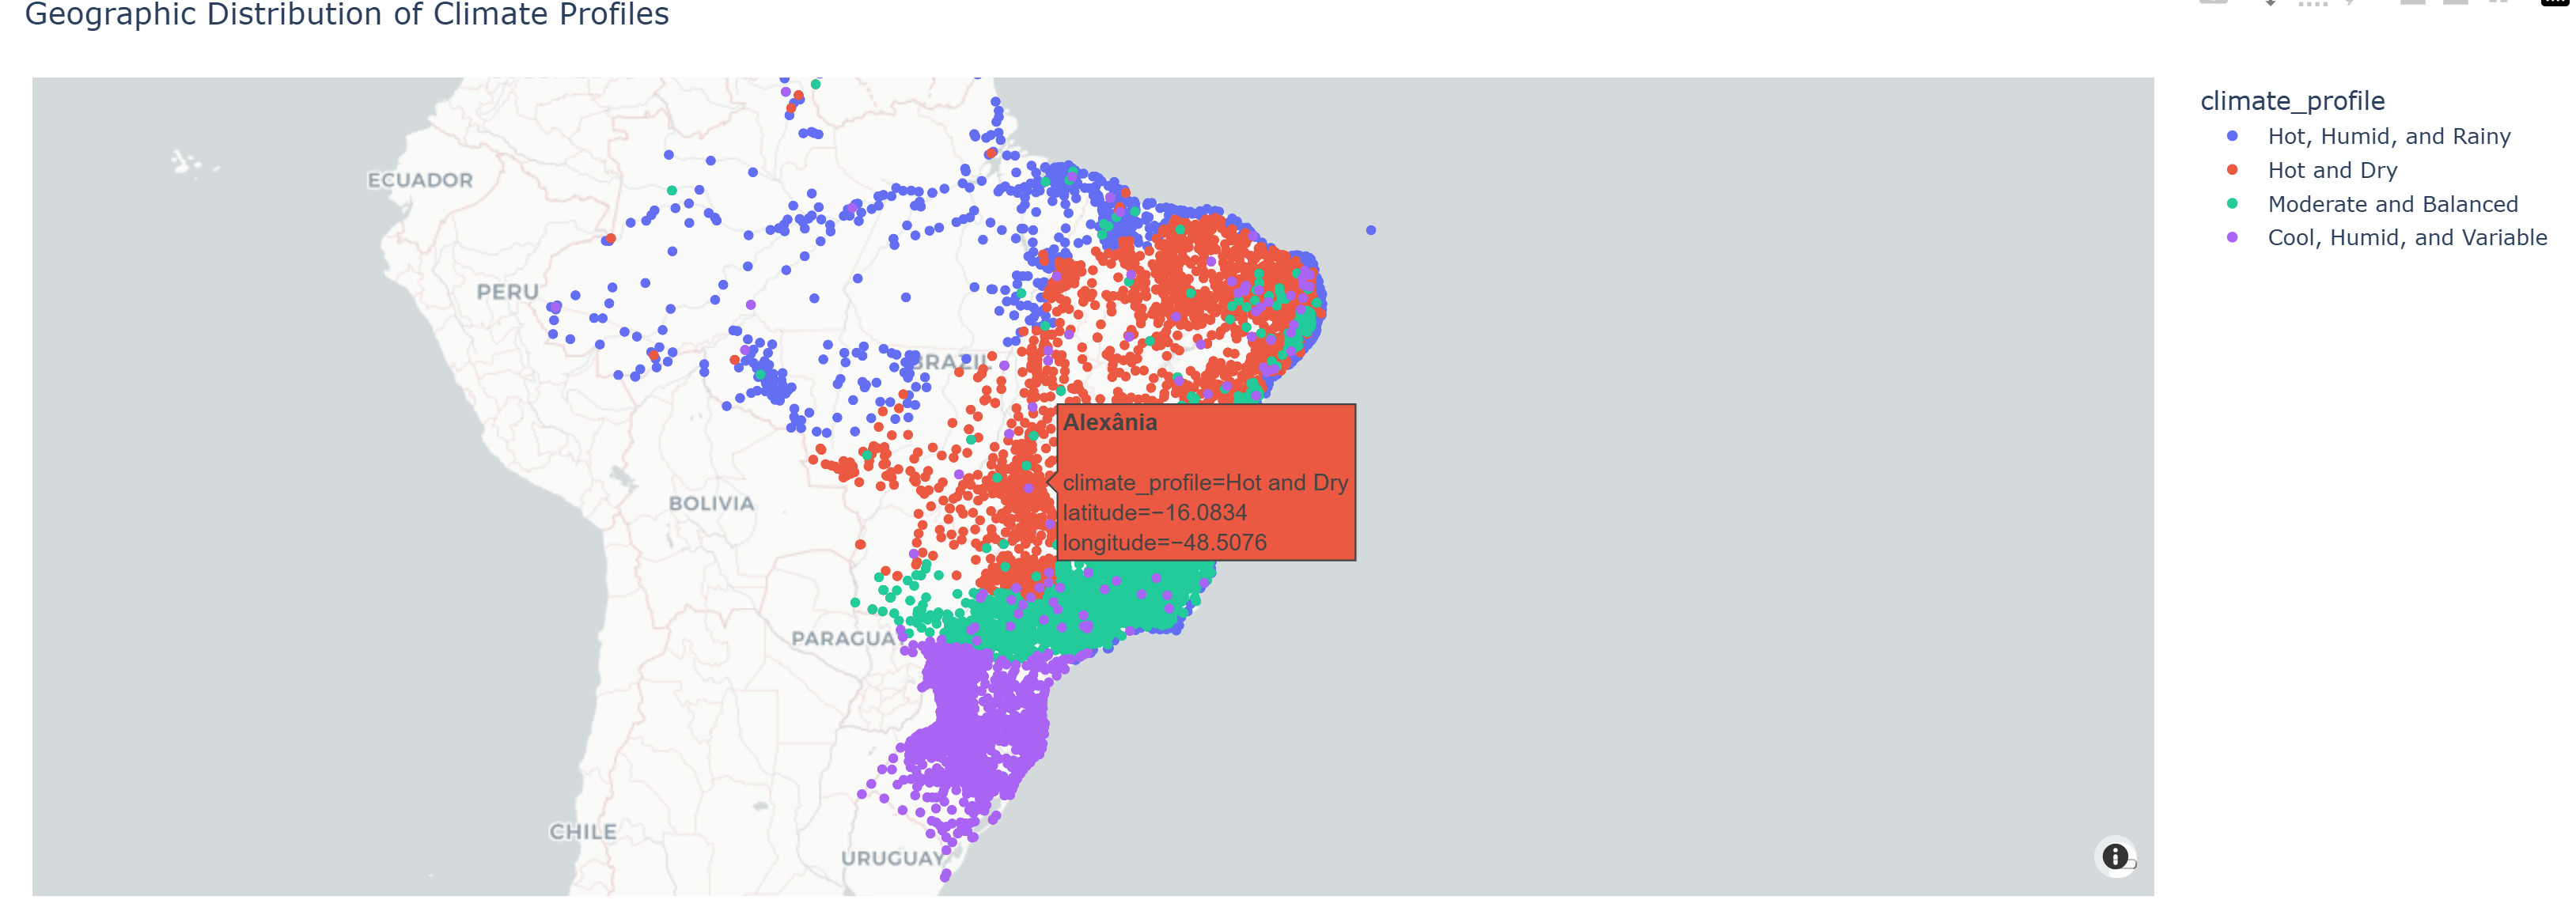

In [ ]:
municipality_name = "Alexânia"
alexania_profile = city_profile[city_profile['municipio'] == municipality_name]

if not alexania_profile.empty:
    print(f"Climate Profile for {municipality_name}:")
    print(alexania_profile[['municipio', 'climate_profile', 'description']].to_string(index=False))
else:
    print(f"Municipality '{municipality_name}' not found in the dataset. Please check the spelling or try a similar query with `semantic_query_system` or `hybrid_query_system`.")

Climate Profile for Alexânia:
municipio climate_profile                                                                                                                                                                                                                                                               description
 Alexânia     Hot and Dry This municipality is moderate, moderately humid, with moderate rainfall and moderate solar exposure. Average temperature is 23.0°C, average humidity is 65.2%, average rainfall is 24.1, and average solar radiation is 20.0. Cluster-based climate profile: Hot and Dry.
